In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

feature_map shape: torch.Size([8, 28, 28])


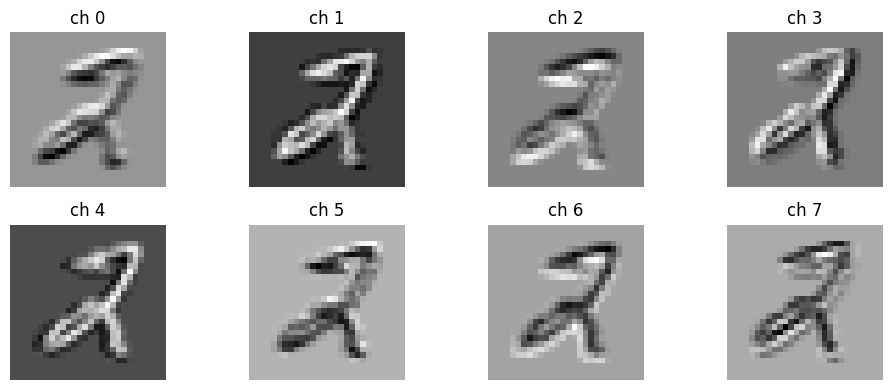

In [10]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
loader = DataLoader(dataset, batch_size=1, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1); self.relu1 = nn.ReLU(); self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1); self.relu2 = nn.ReLU(); self.pool2 = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 7 * 7, 10)
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        return self.fc(torch.flatten(x, 1))

model = SimpleCNN().to(device); features = {}
def hook_fn(module, input, output): features["conv1"] = output.detach().cpu()
handle = model.conv1.register_forward_hook(hook_fn)
X, y = next(iter(loader)); X = X.to(device)
model.eval()
with torch.no_grad(): pred = model(X)
feature_map = features["conv1"][0]
print("feature_map shape:", feature_map.shape)
plt.figure(figsize=(10,4))
for i in range(min(8, feature_map.size(0))):
    plt.subplot(2,4,i+1); plt.imshow(feature_map[i], cmap="gray"); plt.axis("off"); plt.title(f"ch {i}")
plt.tight_layout(); plt.show(); handle.remove()
